# Calibrate

Do imports.

In [566]:
import numpy as np
import matplotlib.pyplot as plt
from ae483.tools import *
from ae483.mytools import *

## Find $l_1$

Load data for a flight in which the drone sat motionless on the hard floor.

In [567]:
raw_data_drone, raw_data_mocap, raw_data_bodies = load_hardware_data('floor.json')

Resample drone data.

You may find that some of the data at the start or end of your flight are garbage. For this reason, `resample_data_drone` has two optional arguments:

* `t_min_offset` is how many seconds you want to ignore (i.e., delete) at the start of the data
* `t_max_offset` is how many seconds you want to ignore (i.e., delete) at the end of the data

To use these arguments effectively, you'll want to plot the data first (evaluate the next three cells to do this, for example) and then go back and play with the offsets. We won't mention these arguments again, but you should consider using them, as necessary, with **every** new dataset you collect and analyze.

In [568]:
data_drone = resample_data_drone(raw_data_drone, t_min_offset=0., t_max_offset=0.)

t = data_drone['time']
z_drone = data_drone['stateEstimate.z']
z_drone_floor = z_drone

Resample mocap data.

In [569]:
data_mocap = resample_data_mocap(raw_data_mocap, t)

z_mocap = data_mocap['z']
z_mocap_floor = z_mocap

Plot data.

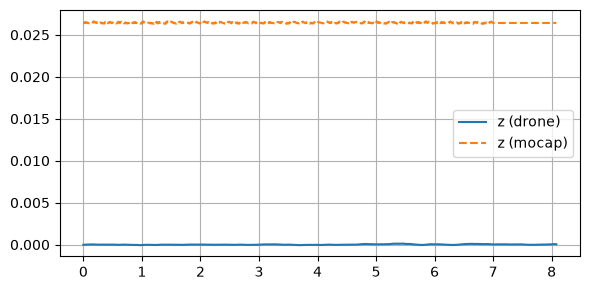

In [570]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3), tight_layout=True)
ax.plot(t, z_drone, label='z (drone)')
ax.plot(t, z_mocap, '--', label='z (mocap)')
ax.legend()
ax.grid()

Find $l_1$ by finding the median of what the mocap measures.

In [571]:
l_1 = np.median(z_mocap)
print(f'l_1 = {l_1:.5f}')

l_1 = 0.02643


# Find $l_2$

Load data for a flight in which the drone sat motionless on the carpet.

In [572]:
raw_data_drone, raw_data_mocap, raw_data_bodies = load_hardware_data('carpet.json')

Resample drone data.

In [573]:
data_drone = resample_data_drone(raw_data_drone, t_min_offset=0., t_max_offset=0.)

t = data_drone['time']
z_drone = data_drone['stateEstimate.z']

Resample mocap data.

In [574]:
data_mocap = resample_data_mocap(raw_data_mocap, t)

z_mocap = data_mocap['z']

Plot data.

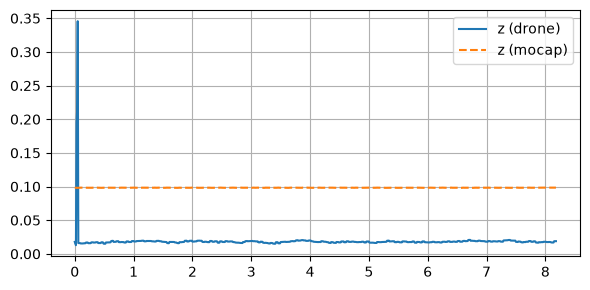

In [575]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3), tight_layout=True)
ax.plot(t, z_drone, label='z (drone)')
ax.plot(t, z_mocap, '--', label='z (mocap)')
ax.legend()
ax.grid()

Find $l_2$ by finding the median of what the mocap measures.

In [576]:
l_2 = np.median(z_mocap)
print(f'l_2 = {l_2:.5f}')

l_2 = 0.09822


In [577]:
carpet = l_2 - l_1
print(f'carpet = {carpet:.5f}')

carpet = 0.07179


# Find $l_3$ and $l_4$

Load data for a flight in which the drone sat motionless on "stilts" on the carpet.

In [578]:
raw_data_drone, raw_data_mocap, raw_data_bodies = load_hardware_data('stilts.json')

Resample drone data.

In [579]:
data_drone = resample_data_drone(raw_data_drone, t_min_offset=0., t_max_offset=0.)

t = data_drone['time']
z_drone = data_drone['stateEstimate.z']

Resample mocap data.

In [580]:
data_mocap = resample_data_mocap(raw_data_mocap, t)

z_mocap = data_mocap['z']

Plot data.

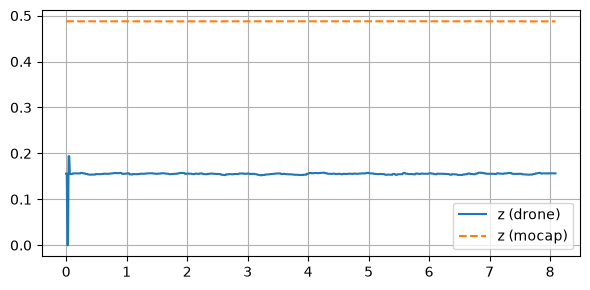

In [581]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3), tight_layout=True)
ax.plot(t, z_drone, label='z (drone)')
ax.plot(t, z_mocap, '--', label='z (mocap)')
ax.legend()
ax.grid()

Find $l_3$ by finding the median of what the drone measures and find $l_4$ by finding the median of what the mocap measures.

In [582]:
l_3 = np.median(z_drone)
l_4 = np.median(z_mocap)
print(f'l_3 = {l_3:.5f}')
print(f'l_4 = {l_4:.5f}')

l_3 = 0.15545
l_4 = 0.48766


# Find $d_1$ and $d_2$

Find $d_1$ by finding the median difference between what the mocap and drone measures when placed on the floor.

In [583]:
d_1 = 0.016
print(f'd_1 = {d_1:.5f}')

d_1 = 0.01600


Find $d_2$ by taking the median of what the drone measures when placed on the floor.

In [584]:
d_2 = 0.009
print(f'd_2 = {d_2:.5f}')

d_2 = 0.00900
